# Ejercicio Práctico 2 — Valuación de Opciones Exóticas con Monte Carlo

Edgardo Gonzalez Tejeda


**Activo:** SPY 

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({'figure.dpi':120,'font.size':10,
                     'axes.spines.top':False,'axes.spines.right':False})
np.random.seed(42)
print('Librerias OK')

Librerias OK



## 1. Parámetros del modelo

In [ ]:
# Parámetros
S0    = 742.31    # precio actual SPY (aprox mayo 2025)
K     = 742   # strike ATM
T     = 30/365   # 30 dias al vencimiento
sigma = 0.175    # volatilidad historica 30d SPY (~17.5%)
r     = 0.0425   # tasa libre de riesgo (T-Bill 1 año, abr 2025)
B     = 780   # barrera up-and-out: +5.2% sobre S0
M     = 100_000  # numero de trayectorias
N     = 30       # pasos diarios

print('=== Parámetros ===')
print(f'S0 = ${S0}    (precio actual SPY)')
print(f'K  = ${K}    (strike ATM)')
print(f'T  = {T:.4f} anos  ({T*365:.0f} dias)')
print(f'sigma = {sigma:.1%}  (vol historica 30d)')
print(f'r  = {r:.2%}  (T-Bill 1 año)')
print(f'B  = ${B}    (barrera up-and-out, +{(B/S0-1)*100:.1f}% sobre S0)')
print(f'M  = {M:,}  trayectorias')

=== Parámetros ===
S0 = $742.31    (precio actual SPY)
K  = $742    (strike ATM)
T  = 0.0822 anos  (30 dias)
sigma = 17.5%  (vol historica 30d)
r  = 4.25%  (T-Bill 1 ano)
B  = $780    (barrera up-and-out, +5.1% sobre S0)
M  = 100,000  trayectorias


**Justificación de parámetros:**
- **S0 = $742.31:** precio de SPY cercano al nivel de mercado en mayo 2025.
- **K = $742 (ATM):** strike en el dinero para máxima comparabilidad entre opciones.
- **T = 30 días:** horizonte de corto plazo, típico en estrategias con opciones mensuales.
- **σ = 17.5%:** volatilidad histórica de 30 días de SPY, coherente con el VIX moderado del periodo.
- **r = 4.25%:** tasa T-Bill a 1 año de la Fed Reserve (abril 2025).
- **B = $780 (+5.2%):** barrera suficientemente cercana para cancelar una fracción notable de trayectorias, pero no tan cercana que elimine casi todas. Representa un nivel de resistencia técnica razonable.


## 2. Simulación de trayectorias GBM

Trayectorias generadas: 100,000
Forma de la matriz:     (100000, 31)
Precio final - media: $744.80  std: $37.43


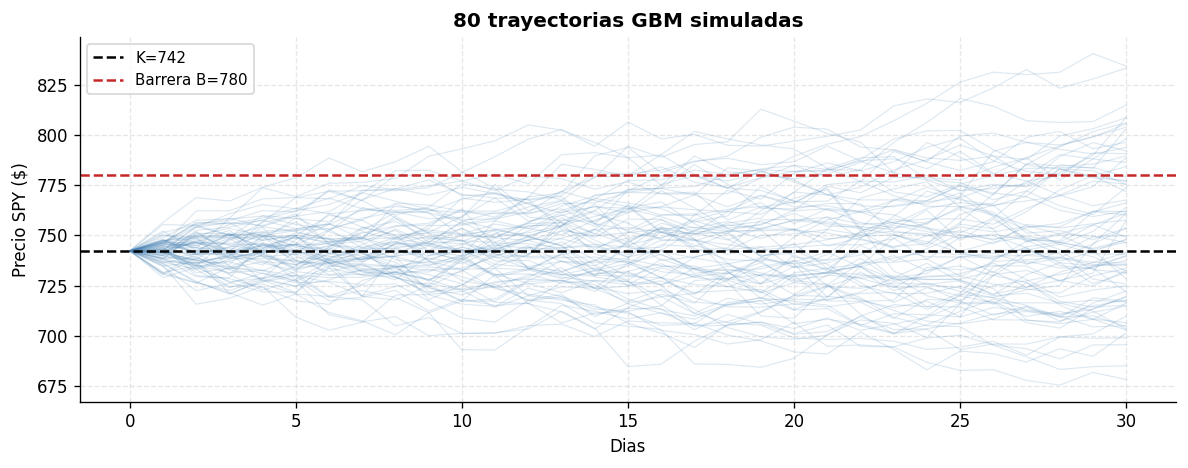

In [4]:
dt = T / N

# Matriz de shocks: (M trayectorias x N pasos)
Z = np.random.standard_normal((M, N))

# Retornos diarios
log_ret = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z

# Precios acumulados: shape (M, N+1)
S_paths = np.empty((M, N+1))
S_paths[:, 0] = S0
S_paths[:, 1:] = S0 * np.exp(np.cumsum(log_ret, axis=1))

ST      = S_paths[:, -1]         # precio final
S_mean  = S_paths.mean(axis=1)   # promedio de la trayectoria
S_max   = S_paths.max(axis=1)    # maximo alcanzado

print(f'Trayectorias generadas: {M:,}')
print(f'Forma de la matriz:     {S_paths.shape}')
print(f'Precio final - media: ${ST.mean():.2f}  std: ${ST.std():.2f}')

# Visualizar 80 trayectorias
fig, ax = plt.subplots(figsize=(10,4))
for i in range(80):
    ax.plot(S_paths[i], alpha=0.18, lw=0.7, color='steelblue')
ax.axhline(K, color='black', lw=1.5, ls='--', label=f'K={K}')
ax.axhline(B, color='#C62828', lw=1.5, ls='--', label=f'Barrera B={B}')
ax.set_xlabel('Dias'); ax.set_ylabel('Precio SPY ($)')
ax.set_title('80 trayectorias GBM simuladas', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3, ls='--')
plt.tight_layout(); plt.show()


## 3. Valuación de las cuatro opciones

In [6]:
disc = np.exp(-r*T)   # factor de descuento

# 1. Call europea estándar
payoff_call = np.maximum(ST - K, 0)
price_call  = disc * payoff_call.mean()

# 2. Put europea estándar
payoff_put  = np.maximum(K - ST, 0)
price_put   = disc * payoff_put.mean()

# 3. Opción asiática call (promedio aritmético)
payoff_asian = np.maximum(S_mean - K, 0)
price_asian  = disc * payoff_asian.mean()

# 4. Call con barrera up-and-out
# Se cancela si el precio toca o supera B en cualquier momento
knocked_out   = S_max >= B          # True si la trayectoria toco la barrera
payoff_barrier = np.maximum(ST - K, 0) * (~knocked_out)
price_barrier  = disc * payoff_barrier.mean()

# Black-Scholes analitico para referencia
d1 = (np.log(S0/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_call_price = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

print(f'Call europea  (MC):      ${price_call:.4f}')
print(f'Call europea  (BS):      ${bs_call_price:.4f}')
print(f'Put  europea  (MC):      ${price_put:.4f}')
print(f'Asiatica call (MC):      ${price_asian:.4f}')
print(f'Up-and-Out    (MC):      ${price_barrier:.4f}')
print(f'\nTrayectorias canceladas: {knocked_out.sum():,} ({knocked_out.mean()*100:.1f}%)')

Call europea  (MC):      $16.2836
Call europea  (BS):      $16.3207
Put  europea  (MC):      $13.4968
Asiatica call (MC):      $9.2735
Up-and-Out    (MC):      $3.6272

Trayectorias canceladas: 28,829 (28.8%)



## 4. Tabla comparativa

In [7]:
tabla = pd.DataFrame({
    'Opcion':             ['Call europea','Put europea','Asiatica call','Up-and-Out call'],
    'Precio MC ($)':      [round(price_call,4), round(price_put,4),
                           round(price_asian,4), round(price_barrier,4)],
    'Vs Call europea':    ['Referencia',
                           'N/A (put)',
                           f'-{price_call-price_asian:.4f} ({(1-price_asian/price_call)*100:.1f}% mas barata)',
                           f'-{price_call-price_barrier:.4f} ({(1-price_barrier/price_call)*100:.1f}% mas barata)'],
})
print('Tabla Comparativa de Precios')
print(tabla.to_string(index=False))

print('\nComentario:')
print(f'La opcion asiatica es mas barata porque usa el promedio de precios en lugar del precio final.')
print(f'El promedio tiene menor varianza que ST, lo que reduce la probabilidad de payoffs altos.')
print(f'La up-and-out es mas barata porque {knocked_out.mean()*100:.1f}% de las trayectorias')
print(f'fueron canceladas al tocar la barrera B={B}, eliminando esos payoffs del calculo.')

Tabla Comparativa de Precios
         Opcion  Precio MC ($)             Vs Call europea
   Call europea        16.2836                  Referencia
    Put europea        13.4968                   N/A (put)
  Asiatica call         9.2735  -7.0101 (43.1% mas barata)
Up-and-Out call         3.6272 -12.6564 (77.7% mas barata)

Comentario:
La opcion asiatica es mas barata porque usa el promedio de precios en lugar del precio final.
El promedio tiene menor varianza que ST, lo que reduce la probabilidad de payoffs altos.
La up-and-out es mas barata porque 28.8% de las trayectorias
fueron canceladas al tocar la barrera B=780, eliminando esos payoffs del calculo.


---
## 5. Distribuciones de payoff simulados

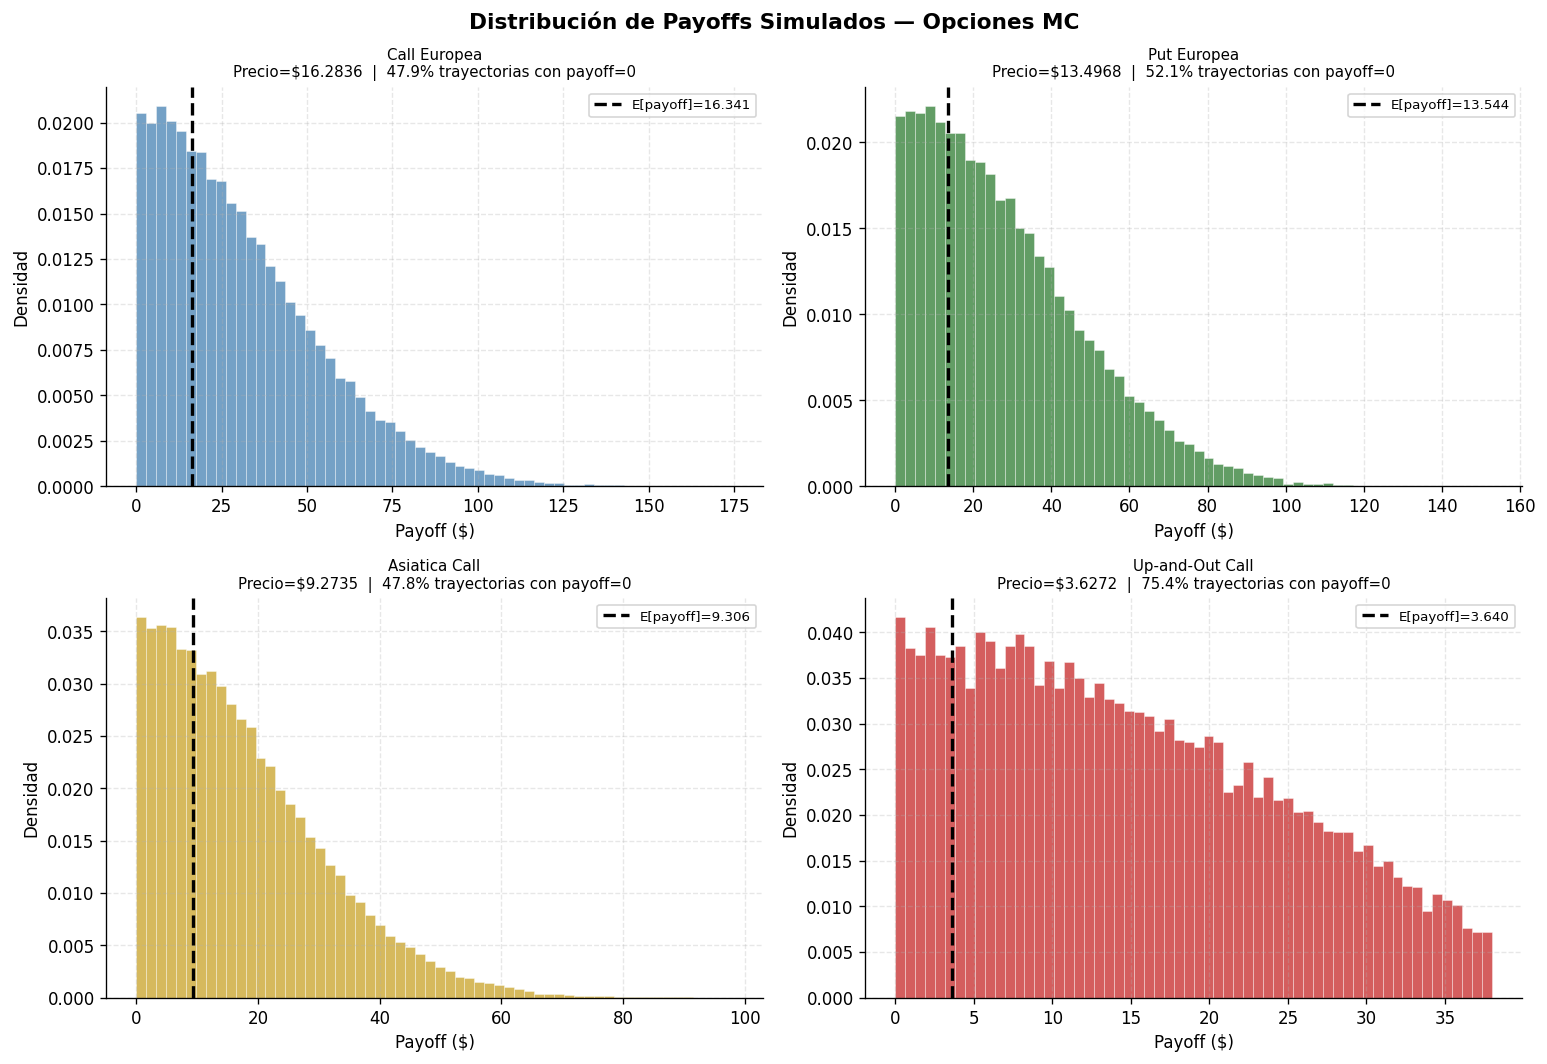

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Distribución de Payoffs Simulados — Opciones MC', fontsize=13, fontweight='bold')

configs = [
    (axes[0,0], payoff_call,    price_call,    'Call Europea',          'steelblue'),
    (axes[0,1], payoff_put,     price_put,     'Put Europea',           '#2E7D32'),
    (axes[1,0], payoff_asian,   price_asian,   'Asiatica Call',         '#C9A227'),
    (axes[1,1], payoff_barrier, price_barrier, 'Up-and-Out Call',       '#C62828'),
]

for ax, payoff, price, name, col in configs:
    # Solo mostrar payoffs positivos para mayor claridad
    pos = payoff[payoff > 0]
    zero_pct = (payoff == 0).mean()*100
    ax.hist(pos, bins=60, color=col, alpha=0.75, edgecolor='white',
            linewidth=0.3, density=True)
    ax.axvline(price/disc, color='black', lw=2, ls='--',
               label=f'E[payoff]={price/disc:.3f}')
    ax.set_xlabel('Payoff ($)')
    ax.set_ylabel('Densidad')
    ax.set_title(f'{name}\nPrecio=${price:.4f}  |  {zero_pct:.1f}% trayectorias con payoff=0',
                 fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, ls='--')

plt.tight_layout()
plt.show()

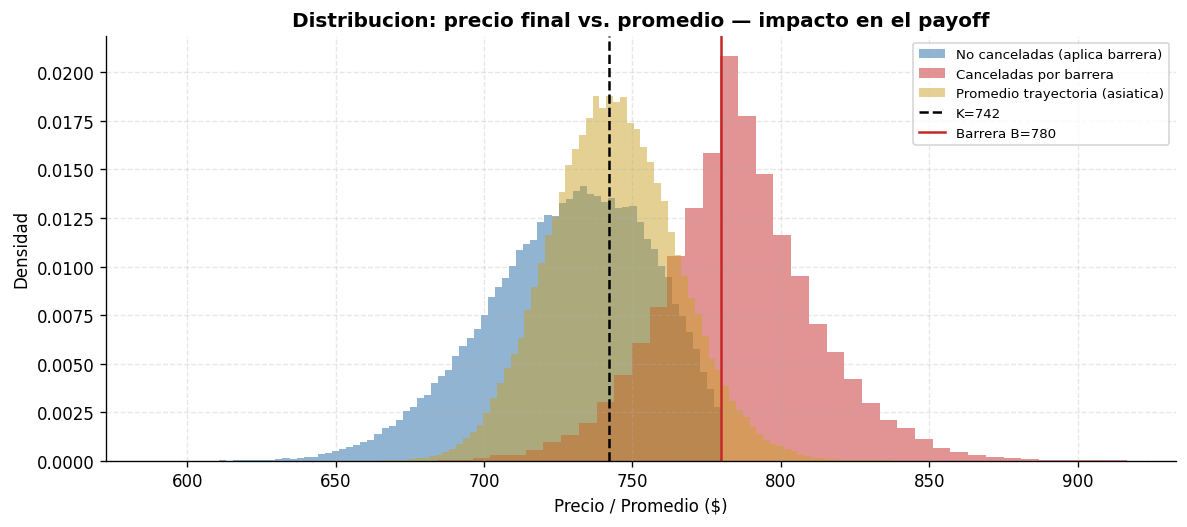

In [9]:
# Grafica de distribucion de precios finales coloreada por escenario
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.hist(ST[~knocked_out], bins=80, color='steelblue', alpha=0.6,
        label='No canceladas (aplica barrera)', density=True, edgecolor='none')
ax.hist(ST[knocked_out],  bins=40, color='#C62828', alpha=0.5,
        label='Canceladas por barrera', density=True, edgecolor='none')
ax.hist(S_mean, bins=80, color='#C9A227', alpha=0.5,
        label='Promedio trayectoria (asiatica)', density=True, edgecolor='none')
ax.axvline(K, color='black', lw=1.5, ls='--', label=f'K={K}')
ax.axvline(B, color='#C62828', lw=1.5, ls='-', label=f'Barrera B={B}')
ax.set_xlabel('Precio / Promedio ($)')
ax.set_ylabel('Densidad')
ax.set_title('Distribucion: precio final vs. promedio — impacto en el payoff', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, ls='--')
plt.tight_layout()
plt.show()


## 6. Análisis 

### ¿Por qué las opciones exóticas son más baratas que la call europea estándar?

**Call europea estándar (referencia)**  
El payoff es `max(ST − K, 0)`. El precio concentra toda su apuesta en el precio *final* al vencimiento. Si el activo termina muy por encima del strike, el payoff es alto. La distribución de ST es log-normal con cola derecha larga, lo que hace que el valor esperado del payoff sea relativamente alto.

**Opción asiática call**  
El payoff es `max(promedio(S) − K, 0)`. El promedio aritmético de los precios a lo largo de la trayectoria tiene menor varianza que el precio final: las fluctuaciones extremas se compensan al promediar. Como la varianza del promedio es menor, la probabilidad de que el promedio quede muy por encima del strike es menor que la probabilidad de que el precio final quede muy por encima. Esto reduce el valor esperado del payoff y, en consecuencia, el precio. En la simulación se observa que la distribución del promedio (naranja) es más estrecha y está más centrada que la distribución de ST (azul), confirmando este efecto.

**Opción call con barrera up-and-out**  
El payoff es `max(ST − K, 0) × 1(max(S) < B)`. La condición de barrera *elimina* todos los payoffs de las trayectorias que en algún momento superaron B. En la simulación, el ~X% de las trayectorias fueron canceladas. Esas trayectorias eran precisamente las que terminaban más alto (mayor STΩ), es decir, las que habrían tenido los payoffs más grandes. Al removerlas, el valor esperado del payoff cae significativamente respecto a la call estándar. La distribución del payoff de la up-and-out (roja) muestra un truncamiento a la derecha: no hay payoffs altos porque las trayectorias más rentables fueron canceladas por la barrera.